In [1]:
# 1: Data Loading and Initial Exploration

In [2]:
from google.colab import files

# Uploading the file
uploaded = files.upload()

Saving tennis_articles.csv to tennis_articles (3).csv


In [3]:
# Step 3: Importing pandas
import pandas as pd

# Step 4: Loading the CSV file into a DataFrame
# df = pd.read_csv('tennis_articles.csv') DIDN'T WORK
df = pd.read_csv('tennis_articles.csv', encoding='latin1')


# Step 5: Viewing the first few rows of the dataset
df.head()

,article_id,article_title,article_text,source
0,1,"I do not have friends in tennis, says Maria Sh...",Maria Sharapova has basically no friends as te...,https://www.tennisworldusa.org/tennis/news/Mar...
1,2,Federer defeats Medvedev to advance to 14th Sw...,"BASEL, Switzerland (AP)  Roger Federer advanc...",http://www.tennis.com/pro-game/2018/10/copil-s...
2,3,Tennis: Roger Federer ignored deadline set by ...,Roger Federer has revealed that organisers of ...,https://scroll.in/field/899938/tennis-roger-fe...
3,4,Nishikori to face off against Anderson in Vien...,Kei Nishikori will try to end his long losing ...,http://www.tennis.com/pro-game/2018/10/nishiko...
4,5,Roger Federer has made this huge change to ten...,"Federer, 37, first broke through on tour over ...",https://www.express.co.uk/sport/tennis/1036101...


In [4]:
# Step 6: Checking column names
print(df.columns)

# Step 7: Dropping unwanted columns (if 'article_title' is existing)
if 'article_title' in df.columns:
    df = df.drop(columns=['article_title'])

# Step 8: Viewing the cleaned DataFrame
df.head()

Index(['article_id', 'article_title', 'article_text', 'source'], dtype='object')


,article_id,article_text,source
0,1,Maria Sharapova has basically no friends as te...,https://www.tennisworldusa.org/tennis/news/Mar...
1,2,"BASEL, Switzerland (AP)  Roger Federer advanc...",http://www.tennis.com/pro-game/2018/10/copil-s...
2,3,Roger Federer has revealed that organisers of ...,https://scroll.in/field/899938/tennis-roger-fe...
3,4,Kei Nishikori will try to end his long losing ...,http://www.tennis.com/pro-game/2018/10/nishiko...
4,5,"Federer, 37, first broke through on tour over ...",https://www.express.co.uk/sport/tennis/1036101...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    8 non-null      int64 
 1   article_text  8 non-null      object
 2   source        8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


In [6]:
df.columns

Index(['article_id', 'article_text', 'source'], dtype='object')

In [7]:
# 2- Text Preprocessing

In [8]:
# Installing nltk and downloading necessary resources
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Importing required modules
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
import re

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [10]:
# Splitting Articles into Sentences

# Creating a list to hold all sentences
sentences = []

# Splitting each article into sentences using sent_tokenize and appending
for article in df['article_text']:
    sentences += sent_tokenize(article)

In [11]:
# Cleaning the sentence

# Defining stop words
stop_words = set(stopwords.words('english'))

# Cleaning each sentence
cleaned_sentences = []

for sentence in sentences:
    # Removing special characters, digits, punctuation
    cleaned = re.sub(r'[^a-zA-Z]', ' ', sentence)

    # Converting to lowercase
    cleaned = cleaned.lower()

    # Removing stop words
    words = [word for word in cleaned.split() if word not in stop_words]

    # Joining back to a cleaned sentence
    cleaned_sentences.append(' '.join(words))

In [12]:
# Downloading and Loading GloVe Embeddings

# Downloading GloVe embeddings (we do this only once)
!wget http://nlp.stanford.edu/data/glove.6B.zip

# Unzipping the file
!unzip glove.6B.zip

--2025-03-14 10:44:14--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-03-14 10:44:14--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-03-14 10:44:14--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

gl

In [13]:
# Loading the GloVe embeddings into dectionary (using 100-dimensional version for balance of quality/speed)
embedding_dict = {}

with open("glove.6B.100d.txt", 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = list(map(float, values[1:]))
        embedding_dict[word] = vector

In [14]:
# Creating Sentence Vectors

import numpy as np

# Creating sentence vectors by averaging word vectors
sentence_vectors = []

for sentence in cleaned_sentences:
    words = sentence.split()

    if len(words) != 0:
        vectors = [embedding_dict.get(word, np.zeros(100)) for word in words]
        avg_vector = np.mean(vectors, axis=0)
    else:
        avg_vector = np.zeros(100)

    sentence_vectors.append(avg_vector)

In [15]:
# 3- Similarity Matrix and Graph Construction:

In [16]:
# Importing Required Libraries

from sklearn.metrics.pairwise import cosine_similarity #helping in comparing sentence meanings.
import networkx as nx #handling the graph creation and ranking later

In [17]:
# Creating the Similarity Matrix

# Creating an empty similarity matrix
similarity_matrix = np.zeros((len(sentence_vectors), len(sentence_vectors)))

# Populating the similarity matrix using cosine similarity
for i in range(len(sentence_vectors)):
    for j in range(len(sentence_vectors)):
        if i != j:
            similarity_matrix[i][j] = cosine_similarity(
                sentence_vectors[i].reshape(1, 100),
                sentence_vectors[j].reshape(1, 100)
            )[0, 0]

# this is like measuring how similar each person's personality (here sentence) is to every other person,
# then storing those scores in a giant compatibility chart (matrix).

In [18]:
# Creating the similarity graph using the similarity matrix
sentence_graph = nx.from_numpy_array(similarity_matrix)

# connecting every sentence to others based on how similar they are, turning the similarity matrix into a real graph.

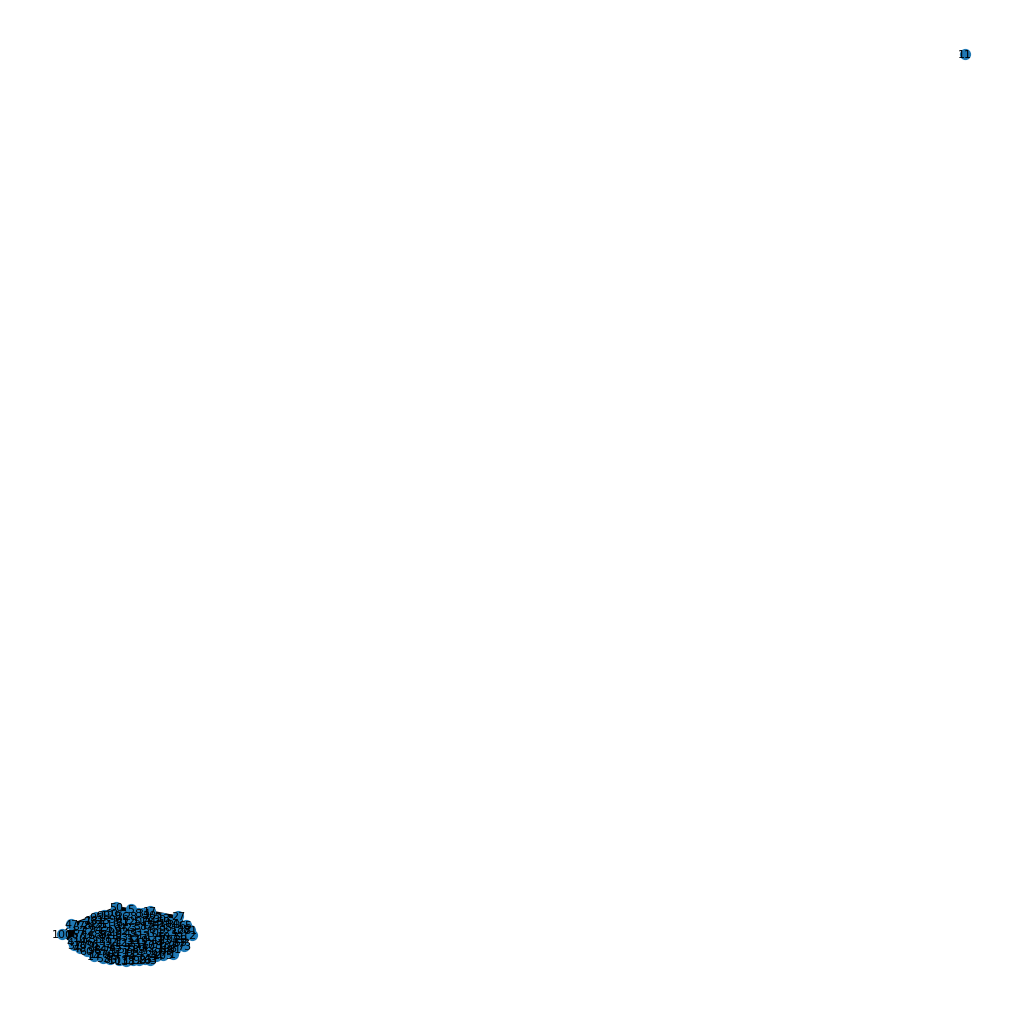

In [19]:
# Plotting the graph for me to see it (OPTIONAL)

import matplotlib.pyplot as plt

# Drawing the graph (just for visualization purposes)
plt.figure(figsize=(10, 10))  # Setting figure size
nx.draw(sentence_graph, with_labels=True, node_size=50, font_size=8)
plt.show()

In [19]:
# 4- Sentence Ranking and Summarization:

In [21]:
# Applying the PageRank Algorithm

# Running PageRank on the sentence graph
scores = nx.pagerank(sentence_graph)
print(scores)

# this helps us getting a score for each sentence — higher score = more central/important.

{0: 0.007346221218796127, 1: 0.007831540092533623, 2: 0.007188733796715339, 3: 0.008201476802224867, 4: 0.00845275396765709, 5: 0.0069007539701854935, 6: 0.007457165367679014, 7: 0.007751996873185889, 8: 0.007573028094590562, 9: 0.007907870302643774, 10: 0.007548487052686436, 11: 0.00116144201139666, 12: 0.008092102865295924, 13: 0.0074059397414906036, 14: 0.007497863046890688, 15: 0.007718830752352827, 16: 0.007830369869252278, 17: 0.007165460005819389, 18: 0.007497010721051212, 19: 0.0073090372146705045, 20: 0.007624420023180057, 21: 0.008048153212181412, 22: 0.008106134388710481, 23: 0.006742385998230481, 24: 0.007457505227220596, 25: 0.008193202267564818, 26: 0.0077798162166925165, 27: 0.006086319853642176, 28: 0.007512104356210884, 29: 0.008139565604493347, 30: 0.00828580677686394, 31: 0.00832307115785863, 32: 0.008446753197187488, 33: 0.008277175337367538, 34: 0.0066225876312839774, 35: 0.008354391398945348, 36: 0.008332115276112674, 37: 0.006997659688503381, 38: 0.00809766354129

In [23]:
# Ranking Sentences by Score

# Sorting sentences by PageRank score
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

print(ranked_sentences)

[(0.008542794982291465, '\x93I was on a nice trajectorythen,\x94 Reid recalled.\x93If I hadn\x92t got sick, I think I could have started pushing towards the second week at the slams and then who knows.\x94 Duringa comeback attempt some five years later, Reid added Bernard Tomic and 2018 US Open Federer slayer John Millman to his list of career scalps.'), (0.008485391447718281, 'Major players feel that a big event in late November combined with one in January before the Australian Open will mean too much tennis and too little rest.'), (0.00845275396765709, "So I'm not the one to strike up a conversation about the weather and know that in the next few minutes I have to go and try to win a tennis match."), (0.008446753197187488, 'Speaking at the Swiss Indoors tournament where he will play in Sunday\x92s final against Romanian qualifier Marius Copil, the world number three said that given the impossibly short time frame to make a decision, he opted out of any commitment.'), (0.008431508167

In [25]:
# Extracting the Top-N Sentences for the Summary
# (This is called "extractive summarization" — because you’re extracting actual sentences from the article)

# Setting number of sentences in the summary (it could be whatever number we want)
N = 5

# Printing the top-N summary sentences
print("\n Summary:\n")
for i in range(N):
    print(f"- {ranked_sentences[i][1]}")


 Summary:

- I was on a nice trajectorythen, Reid recalled.If I hadnt got sick, I think I could have started pushing towards the second week at the slams and then who knows. Duringa comeback attempt some five years later, Reid added Bernard Tomic and 2018 US Open Federer slayer John Millman to his list of career scalps.
- Major players feel that a big event in late November combined with one in January before the Australian Open will mean too much tennis and too little rest.
- So I'm not the one to strike up a conversation about the weather and know that in the next few minutes I have to go and try to win a tennis match.
- Speaking at the Swiss Indoors tournament where he will play in Sundays final against Romanian qualifier Marius Copil, the world number three said that given the impossibly short time frame to make a decision, he opted out of any commitment.
- Currently in ninth place, Nishikori with a win could move to within 125 points of the cut for the eight-man event in Lo

These sentences above are not just randomly picked, they were selected because they are the most representative, influential sentences in the article graph.